# Exploratory Data Analysis (EDA) - IMD2020 Dataset

## 1. Dataset Introduction

IMD2020 merupakan dataset yang digunakan untuk tugas **Image Manipulation Localization**.

Dataset ini berisi pasangan gambar hasil manipulasi (edited image) dan ground truth mask yang menunjukkan lokasi piksel yang mengalami manipulasi.

Tujuan model bukan hanya mengklasifikasikan gambar sebagai asli atau hasil manipulasi, tetapi juga melakukan segmentasi area manipulasi pada tingkat piksel (pixel-wise localization).

### Dataset Components

- **fake_img/**
  Berisi gambar hasil manipulasi.

- **mask/**
  Berisi binary mask sebagai ground truth.
  - Putih : area manipulasi
  - Hitam : area asli

- **fake.txt**
  Berisi daftar nama gambar yang digunakan sebagai pasangan antara image dan mask.

### Tujuan EDA

Exploratory Data Analysis dilakukan untuk memahami karakteristik dataset sebelum proses preprocessing dan training model dilakukan.

In [ ]:
# Import library 
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [3]:
# Menentukan lokasi dataset

DATASET_PATH = Path("IMD2020")
DATASET_PATH

WindowsPath('IMD2020')

In [4]:
# Memastikan folder dataset tersedia

DATASET_PATH.exists()

True

## 2. Folder Structure

Sebelum melakukan analisis lebih lanjut, perlu dipahami terlebih dahulu bagaimana struktur penyimpanan dataset.

Pada tahap ini dilakukan eksplorasi terhadap folder utama IMD2020 untuk mengetahui komponen dataset beserta isi masing-masing folder.

In [5]:
# Menampilkan seluruh isi folder utama dataset IMD2020

os.listdir(DATASET_PATH)

['fake.txt', 'fake_img', 'mask']

In [6]:
# Menentukan lokasi setiap komponen dataset

FAKE_IMG_PATH = DATASET_PATH / "fake_img"
MASK_PATH = DATASET_PATH / "mask"
FAKE_TXT_PATH = DATASET_PATH / "fake.txt"

In [7]:
# Memastikan seluruh komponen dataset tersedia

print(f"fake_img : {FAKE_IMG_PATH.exists()}")
print(f"mask     : {MASK_PATH.exists()}")
print(f"fake.txt : {FAKE_TXT_PATH.exists()}")

fake_img : True
mask     : True
fake.txt : True


In [8]:
# Menampilkan isi folder fake_img (10 file pertama)

os.listdir(FAKE_IMG_PATH)[:10]

['00006_fake.jpg',
 '00009_fake.jpg',
 '00010_fake_01.jpg',
 '00010_fake_02.png',
 '00011_fake.jpg',
 '00015_fake.jpg',
 '00016_fake.jpg',
 '00018_fake.jpg',
 '00021_fake.jpg',
 '00022_fake.jpg']

In [9]:
# Menampilkan isi folder mask (10 file pertama)

os.listdir(MASK_PATH)[:10]

['00006_fake_mask.png',
 '00009_fake_mask.png',
 '00010_fake_01_mask.png',
 '00010_fake_02_mask.png',
 '00011_fake_mask.png',
 '00015_fake_mask.png',
 '00016_fake_mask.png',
 '00018_fake_mask.png',
 '00021_fake_mask.png',
 '00022_fake_mask.png']

In [10]:
# Membaca beberapa baris pertama dari file fake.txt

with open(FAKE_TXT_PATH, "r") as file:
    lines = file.readlines()

lines[:10]

['00006_fake.jpg\n',
 '00009_fake.jpg\n',
 '00010_fake_01.jpg\n',
 '00010_fake_02.png\n',
 '00011_fake.jpg\n',
 '00015_fake.jpg\n',
 '00016_fake.jpg\n',
 '00018_fake.jpg\n',
 '00021_fake.jpg\n',
 '00022_fake.jpg\n']

## 3. Dataset Summary

Setelah mengetahui struktur dataset, langkah berikutnya adalah membuat ringkasan mengenai jumlah data yang tersedia.

Pada tahap ini dilakukan identifikasi jumlah gambar manipulasi, jumlah mask, serta jumlah data yang tercatat pada file `fake.txt`. Hasil analisis ini memberikan gambaran awal mengenai ukuran dataset yang akan digunakan pada proses penelitian.

In [15]:
# Mengambil seluruh file gambar pada folder fake_img

VALID_IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

image_files = sorted([
    file
    for file in os.listdir(FAKE_IMG_PATH)
    if file.lower().endswith(VALID_IMAGE_EXTENSIONS)
])

In [16]:
# Mengambil seluruh file mask pada folder mask

mask_files = sorted([
    file
    for file in os.listdir(MASK_PATH)
    if file.lower().endswith(".png")
])

In [17]:
# Membaca seluruh nama file pada fake.txt

with open(FAKE_TXT_PATH, "r") as file:
    fake_txt = [line.strip() for line in file]

In [18]:
# Menghitung jumlah data pada setiap komponen dataset

num_fake_images = len(image_files)
num_masks = len(mask_files)
num_fake_txt = len(fake_txt)

In [19]:
print(f"Number of manipulated images : {num_fake_images}")
print(f"Number of masks              : {num_masks}")
print(f"Number of entries in fake.txt: {num_fake_txt}")

Number of manipulated images : 2010
Number of masks              : 2010
Number of entries in fake.txt: 2010


## 4. File Consistency Check

Sebelum dataset digunakan pada proses preprocessing maupun training model, perlu dipastikan bahwa setiap gambar manipulasi memiliki pasangan binary mask yang sesuai.

Pada tahap ini dilakukan pemeriksaan konsistensi antara:

- file pada folder `fake_img`
- file pada folder `mask`
- daftar file pada `fake.txt`

Pemeriksaan ini bertujuan untuk memastikan tidak terdapat data yang hilang maupun pasangan file yang tidak sesuai.

In [20]:
# Mengubah nama image menjadi nama mask yang seharusnya

def image_to_mask_name(image_name):
    stem = Path(image_name).stem
    return f"{stem}_mask.png"

In [21]:
# Membuat daftar nama mask berdasarkan nama image

expected_masks = {
    image_to_mask_name(image)
    for image in image_files
}

In [22]:
# Mencari image yang belum memiliki pasangan mask

missing_masks = expected_masks - set(mask_files)

len(missing_masks)

0

In [23]:
# Mencari mask yang tidak memiliki pasangan image

extra_masks = set(mask_files) - expected_masks

len(extra_masks)

0

In [24]:
# Membandingkan image pada folder dengan fake.txt

missing_in_txt = set(image_files) - set(fake_txt)

len(missing_in_txt)

0

In [25]:
# Menampilkan image yang tidak tercantum pada fake.txt

missing_in_txt

set()

In [26]:
# Menampilkan hasil pemeriksaan konsistensi dataset

print(f"Image without mask : {len(missing_masks)}")
print(f"Mask without image : {len(extra_masks)}")
print(f"Image missing in fake.txt : {len(missing_in_txt)}")

Image without mask : 0
Mask without image : 0
Image missing in fake.txt : 0


## 5. Image Resolution Analysis

Ukuran (resolusi) gambar merupakan salah satu karakteristik penting dalam dataset computer vision karena berpengaruh terhadap proses preprocessing dan training model.

Pada tahap ini dilakukan analisis terhadap dimensi setiap gambar untuk mengetahui apakah seluruh gambar memiliki ukuran yang seragam atau bervariasi.

In [27]:
# Mengambil resolusi setiap gambar pada folder fake_img

image_sizes = []

for image_name in image_files:
    
    image = Image.open(FAKE_IMG_PATH / image_name)
    
    width, height = image.size
    
    image_sizes.append({
        "Filename": image_name,
        "Width": width,
        "Height": height
    })

In [29]:
# Mengubah hasil pengukuran menjadi DataFrame

resolution_df = pd.DataFrame(image_sizes)

resolution_df.head()

,Filename,Width,Height
0,00006_fake.jpg,1200,836
1,00009_fake.jpg,960,720
2,00010_fake_01.jpg,860,777
3,00010_fake_02.png,808,632
4,00011_fake.jpg,700,500


In [30]:
# Menampilkan lima data pertama beserta resolusinya

resolution_df

,Filename,Width,Height
0,00006_fake.jpg,1200,836
1,00009_fake.jpg,960,720
2,00010_fake_01.jpg,860,777
3,00010_fake_02.png,808,632
4,00011_fake.jpg,700,500
...,...,...,...
2005,c9xup2p_0.png,620,387
2006,c9xuxck_0.jpg,2479,1653
2007,c9xv7da_0.jpg,1200,800
2008,c9xwa8e_0.jpg,736,479


In [31]:
# Menampilkan statistik deskriptif resolusi gambar

resolution_df[["Width","Height"]].describe()

,Width,Height
count,2010.000000,2010.000000
mean,1056.098507,848.522886
std,611.350390,484.088976
min,219.000000,176.000000
25%,634.250000,536.000000
50%,926.000000,720.000000
75%,1224.000000,988.000000
max,4300.000000,4437.000000


In [32]:
# Menampilkan jumlah resolusi unik pada dataset

resolution_df[["Width","Height"]].drop_duplicates()

,Width,Height
0,1200,836
1,960,720
2,860,777
3,808,632
4,700,500
...,...,...
2002,1741,1125
2003,512,512
2005,620,387
2006,2479,1653


In [33]:
# Menghitung frekuensi setiap resolusi gambar

resolution_df.value_counts(
    ["Width","Height"]
).reset_index(name="Count")

,Width,Height,Count
0,960,720,29
1,1920,1080,22
2,1024,768,21
3,1600,1200,19
4,720,960,17
...,...,...,...
1111,1741,1125,1
1112,512,512,1
1113,620,387,1
1114,2479,1653,1


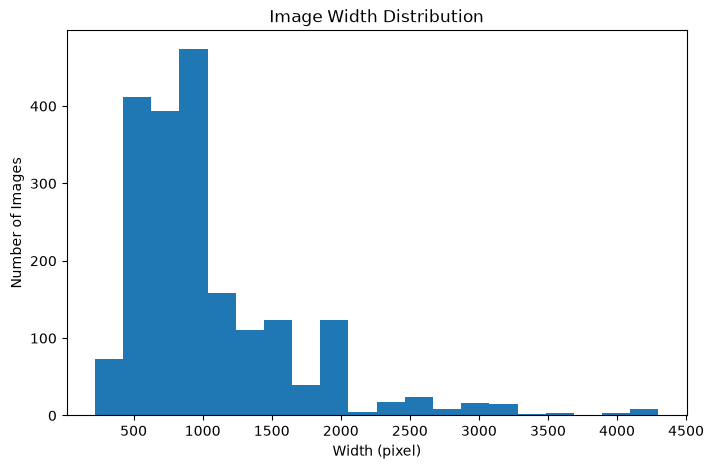

In [34]:
# Visualisasi distribusi lebar gambar

plt.figure(figsize=(8,5))

plt.hist(resolution_df["Width"], bins=20)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixel)")
plt.ylabel("Number of Images")

plt.show()

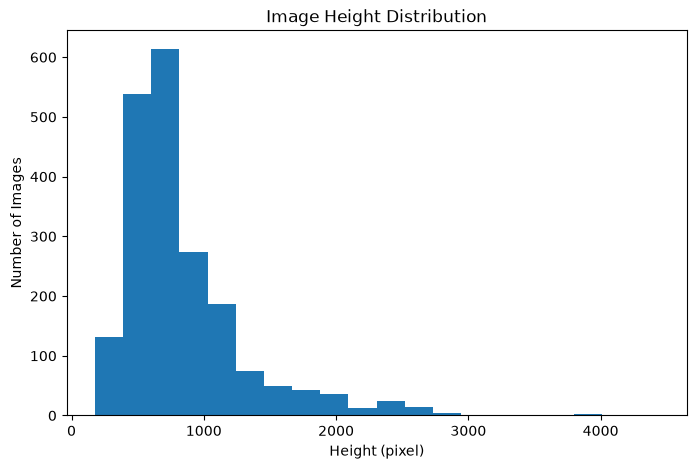

In [35]:
# Visualisasi distribusi tinggi gambar

plt.figure(figsize=(8,5))

plt.hist(resolution_df["Height"], bins=20)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixel)")
plt.ylabel("Number of Images")

plt.show()